In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training Images Shape:", x_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Images Shape:", x_test.shape)
print("Testing Labels Shape:", y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 28s 0us/step
Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Testing Images Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


In [4]:

x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

print("x_train normalized shape:", x_train.shape)
print("x_test normalized shape:", x_test.shape)
print("x_train min value:", x_train.min())
print("x_train max value:", x_train.max())

x_train normalized shape: (50000, 32, 32, 3)
x_test normalized shape: (10000, 32, 32, 3)
x_train min value: 0
x_train max value: 255


In [5]:
x_train_ann = x_train_norm.reshape(50000, 3072)
x_test_ann = x_test_norm.reshape(10000, 3072)

print(x_train_ann.shape)

(50000, 3072)


In [6]:
ann_model = models.Sequential([

    layers.Dense(1024,
                 activation='relu',
                 input_shape=(3072,)),

    layers.Dropout(0.3),

    layers.Dense(512,
                 activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(256,
                 activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(128,
                 activation='relu'),

    layers.Dense(10,
                 activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [9]:
ann_history = ann_model.fit(
    x_train_ann,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 71ms/step - accuracy: 0.2289 - loss: 2.0640 - val_accuracy: 0.2972 - val_loss: 1.8856
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.2891 - loss: 1.9221 - val_accuracy: 0.3310 - val_loss: 1.8626
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 72ms/step - accuracy: 0.3073 - loss: 1.8750 - val_accuracy: 0.3530 - val_loss: 1.8198
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.3132 - loss: 1.8616 - val_accuracy: 0.3520 - val_loss: 1.8041
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 69ms/step - accuracy: 0.3313 - loss: 1.8209 - val_accuracy: 0.3672 - val_loss: 1.7730
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 69ms/step - accuracy: 0.3345 - loss: 1.8083 - val_accuracy: 0.3866 - val_loss: 1.7249
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.3373 - loss: 1.8049 - val_accuracy: 0.3796 - val_loss: 1.7583
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 71ms/step - accuracy: 0.3498 - loss: 1.7828 - 

In [11]:
ann_loss, ann_test_acc = ann_model.evaluate(
    x_test_ann,
    y_test
)

print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3929 - loss: 1.7048
ANN Test Accuracy: 0.3928999900817871


In [13]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(32,32,3)
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        128,
        (3,3),
        padding='same',
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        256,
        activation='relu'
    ),

    layers.Dropout(0.4),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.3),

    layers.Dense(
        10,
        activation='softmax'
    )
])

cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,874 (2.49 MB)

 Trainable params: 652,426 (2.49 MB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [16]:
cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 154s 215ms/step - accuracy: 0.4204 - loss: 1.6235 - val_accuracy: 0.5660 - val_loss: 1.2444
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 193s 202ms/step - accuracy: 0.5841 - loss: 1.1877 - val_accuracy: 0.4248 - val_loss: 1.7783
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 202ms/step - accuracy: 0.6551 - loss: 1.0027 - val_accuracy: 0.5980 - val_loss: 1.1673
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 200ms/step - accuracy: 0.6966 - loss: 0.8801 - val_accuracy: 0.6558 - val_loss: 0.9987
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 205ms/step - accuracy: 0.7361 - loss: 0.7779 - val_accuracy: 0.6884 - val_loss: 0.9365
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 201ms/step - accuracy: 0.7562 - loss: 0.7116 - val_accuracy: 0.7284 - val_loss: 0.7795
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 205ms/step - accuracy: 0.7786 - loss: 0.6468 - val_accuracy: 0.6496 - val_loss: 1.0254
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 205ms/step - accuracy: 0.8041 -

In [17]:
cnn_loss, cnn_test_acc = cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.7605 - loss: 0.8056
CNN Test Accuracy: 0.7605000138282776


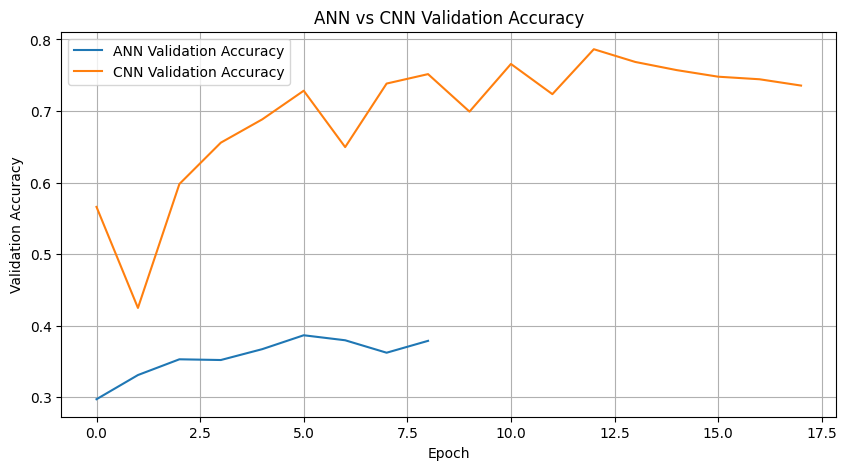

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    ann_history.history['val_accuracy'],
    label='ANN Validation Accuracy'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='CNN Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [19]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [20]:
aug_cnn_model = models.Sequential([

    data_augmentation,

    layers.Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(32,32,3)
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        128,
        (3,3),
        padding='same',
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        256,
        activation='relu'
    ),

    layers.Dropout(0.4),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.3),

    layers.Dense(
        10,
        activation='softmax'
    )
])

In [21]:
aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 157s 216ms/step - accuracy: 0.3666 - loss: 1.7680 - val_accuracy: 0.4646 - val_loss: 1.4981
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 204s 219ms/step - accuracy: 0.4839 - loss: 1.4472 - val_accuracy: 0.5498 - val_loss: 1.2421
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 153s 217ms/step - accuracy: 0.5378 - loss: 1.3068 - val_accuracy: 0.5668 - val_loss: 1.2339
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 152s 216ms/step - accuracy: 0.5763 - loss: 1.2203 - val_accuracy: 0.5896 - val_loss: 1.1401
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 153s 217ms/step - accuracy: 0.6020 - loss: 1.1493 - val_accuracy: 0.6542 - val_loss: 0.9998


In [23]:
aug_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Test Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.4576 - loss: 1.4933
Augmented CNN Test Accuracy: 0.4575999975204468


In [24]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model":[
        "ANN",
        "CNN",
        "Augmented CNN"
    ],
    "Test Accuracy":[
        ann_test_acc,
        cnn_test_acc,
        aug_test_acc
    ]
})

print(comparison_df)

           Model  Test Accuracy
0            ANN         0.3929
1            CNN         0.7605
2  Augmented CNN         0.4576


In [25]:
best_model = comparison_df.loc[
    comparison_df['Test Accuracy'].idxmax()
]

print(best_model)

Model               CNN
Test Accuracy    0.7605
Name: 1, dtype: object
